# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 2 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2252_data_3402_001-NLyiqHJ5btv8Y/Shared%20Documents/General/Kaggle%20Tabular%20Datasets.xlsx?d=w34cdd3378d1146a2ab63700189a8c5b5&csf=1&web=1&e=6ASD5s). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please go check with Dr. Farbin to make sure it is viable.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects.

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


In [ ]:
# Link: https://www.kaggle.com/datasets/uciml/mushroom-classification

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/media/scott/KESU/DATA3402/DATA3402FinalProject/mushrooms.csv")

# Number of rows and features
numrows, numcolumns = df.shape
print(f"Rows: {numrows}")
print(f"Number of features: {numcolumns}", "\n")

# Missing values check
missingvaluecheck = df.isnull().sum()
print(missingvaluecheck, "\n")

# Table
featuretable = []
for column in df.columns:
    data = df[column]
    if pd.api.types.is_numeric_dtype(data):
        feattype = "Numerical"
    else:
        feattype = "Categorical"
    values = data.dropna().unique()[:10]

    featuretable.append({
        "Feature": column,
        "Type": feattype,
        "Values": values,
        "Missing values": data.isnull().sum()
    })
summarytable = pd.DataFrame(featuretable)
summarytable.set_index("Feature", inplace = True)
print(summarytable, "\n")

# Checking class imbalance
classcounts = df["class"].value_counts()
print(classcounts, "\n")

# Encoding the target "Class"
le = LabelEncoder()
df["class_encoded"] = le.fit_transform(df["class"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

Rows: 8124
Number of features: 23 

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64 

                                 Type                          Values  \
Feature                                                                 
class                     Categorical                          [p, e]   
cap-shape                 Categorical   

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

/tmp/ipykernel_20724/3909921737.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (6,4))


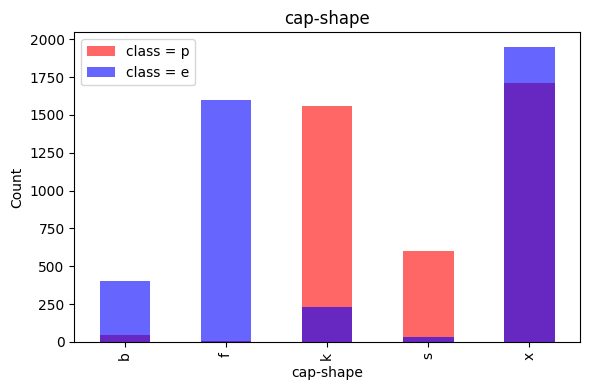

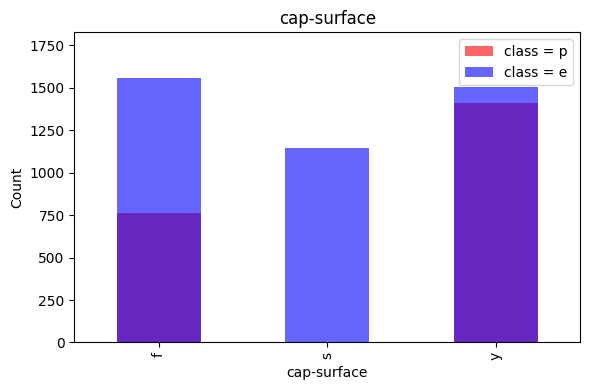

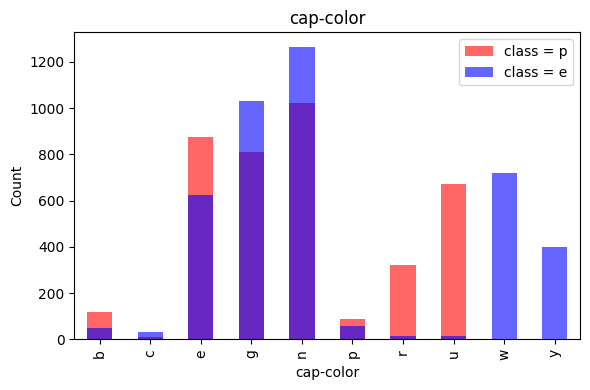

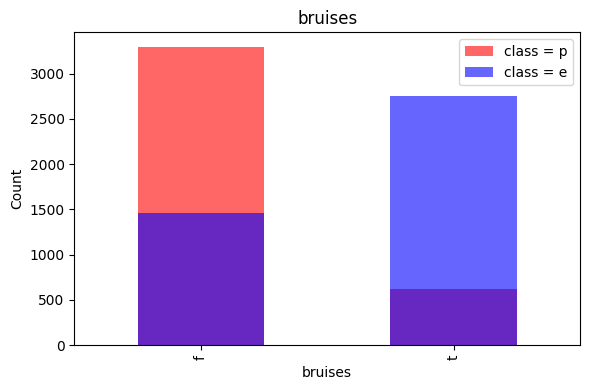

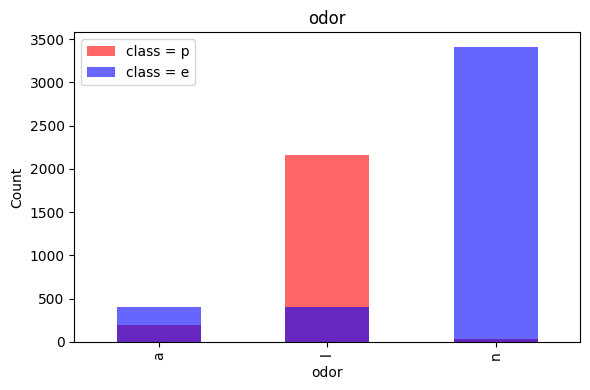

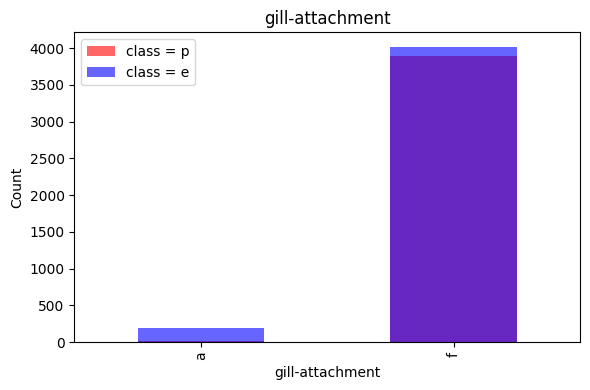

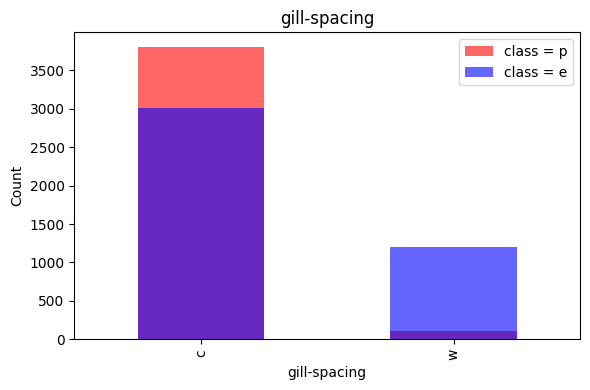

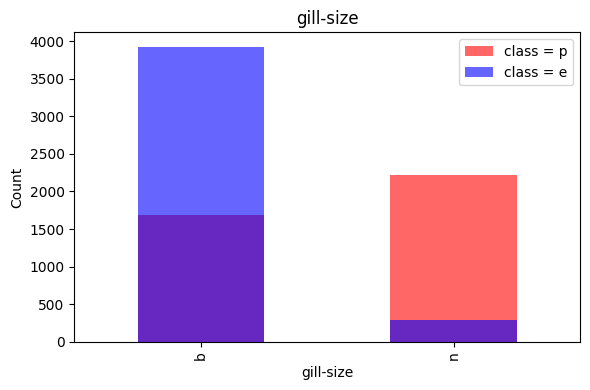

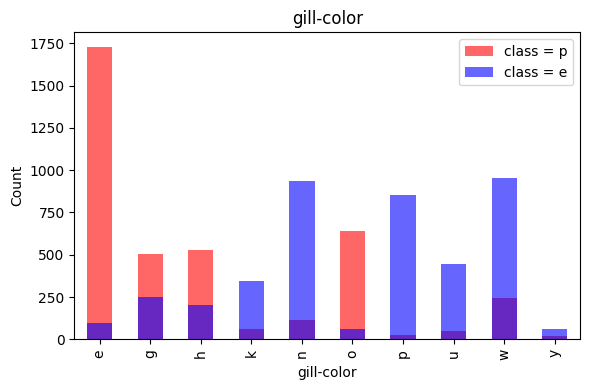

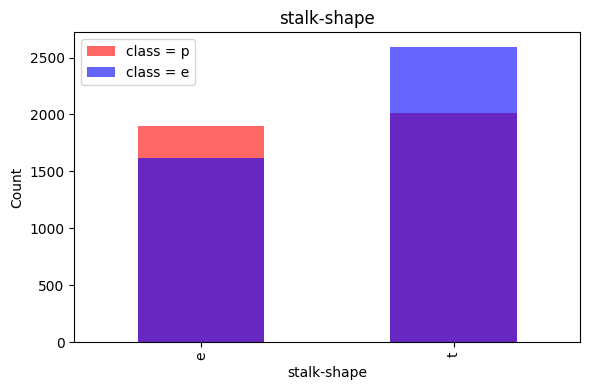

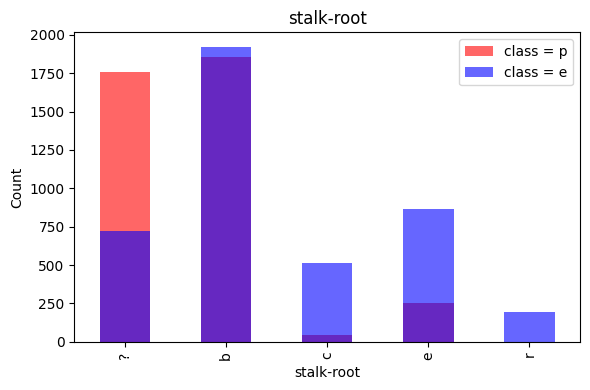

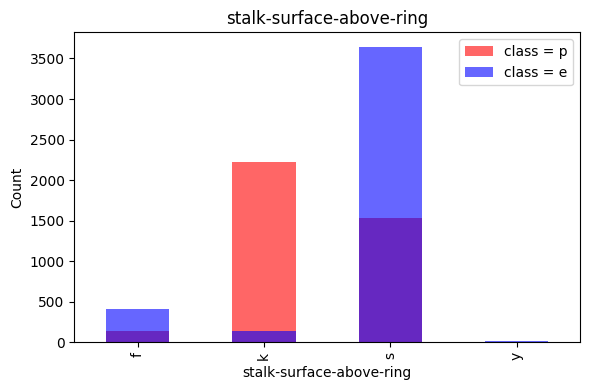

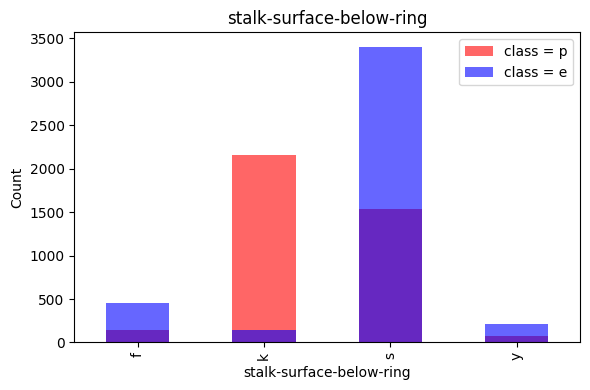

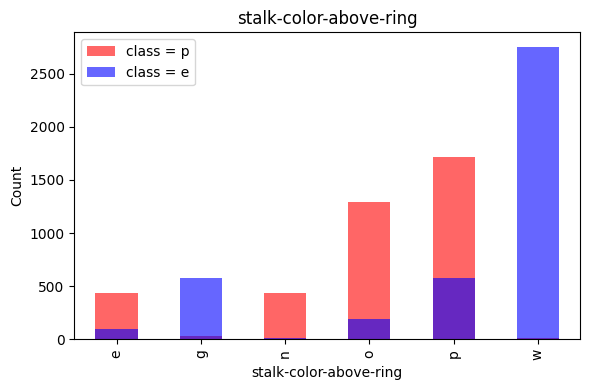

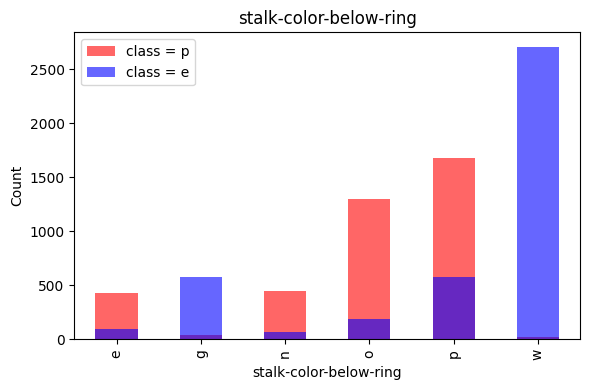

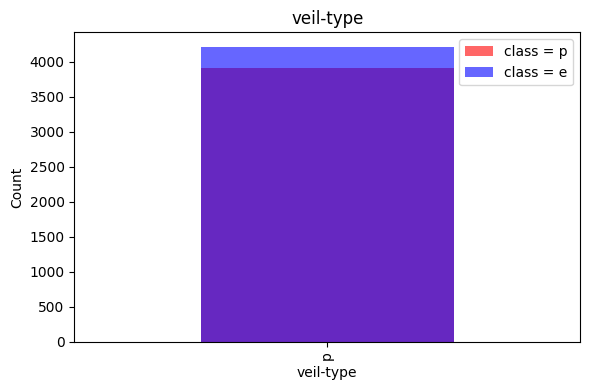

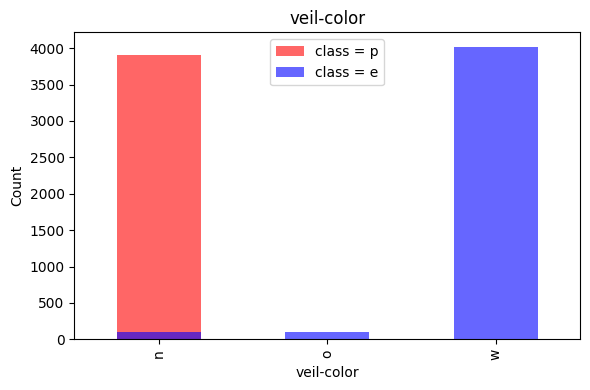

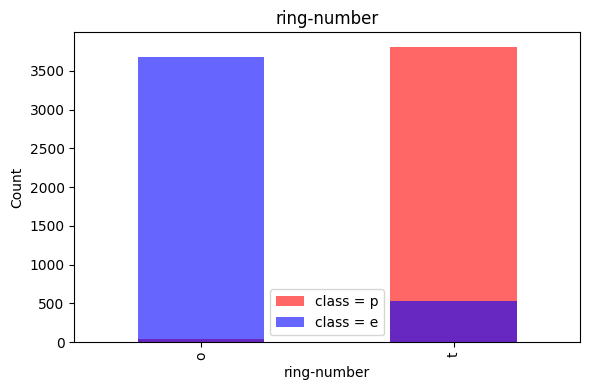

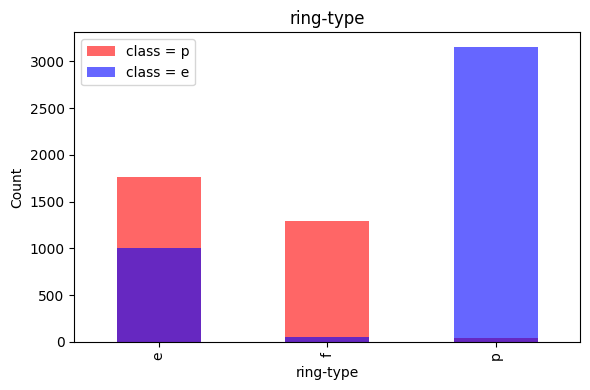

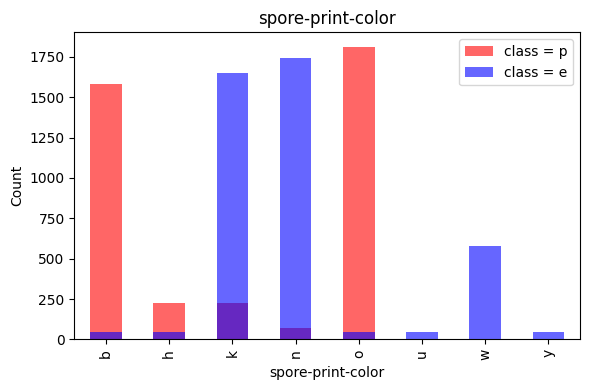

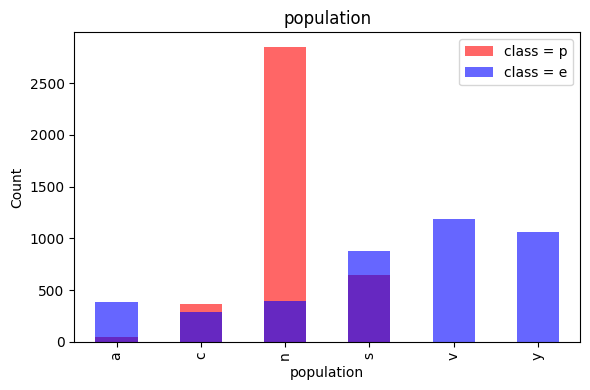

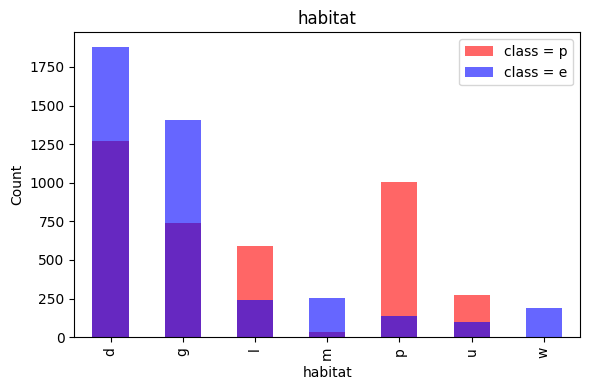

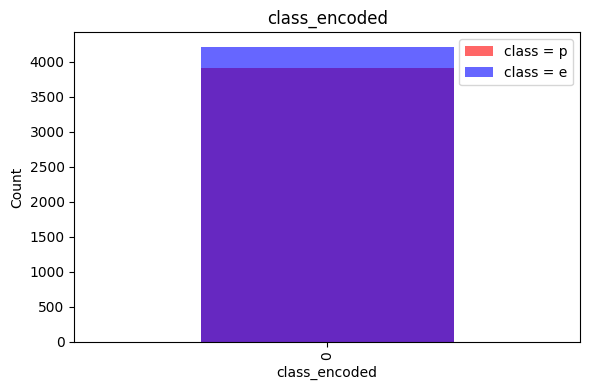

In [14]:
import matplotlib.pyplot as plt

classcolor = {"e": "blue", "p": "red"}

target = "class"
features = [col for col in df.columns if col != target]
for feat in features:
    plt.figure(figsize = (6,4))
    for classval in df[target].unique():
        subset = df[df[target] == classval]
        subset[feat].value_counts().sort_index().plot(kind = "bar", alpha = 0.6, color = classcolor[classval], label = f"{target} = {classval}")

    plt.title(f"{feat}")
    plt.xlabel(feat)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show

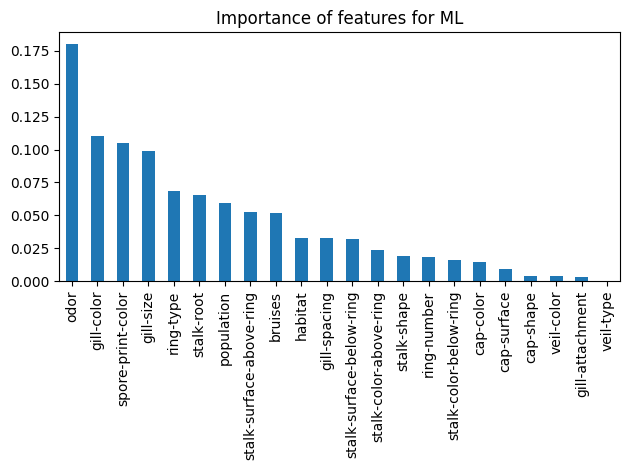

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

x = df.drop(["class", "class_encoded"], axis = 1).apply(LabelEncoder().fit_transform)
y = df["class_encoded"]

model1 = RandomForestClassifier(random_state = 42)
model1.fit(x,y)

importances = pd.Series(model1.feature_importances_, index = x.columns)
importances.sort_values(ascending = False).plot(kind = "bar", title = "Importance of features for ML")
plt.tight_layout()
plt.show()

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [32]:
# Replacing ? values with NaN so that missing values can be indentified
df.replace("?", pd.NA, inplace = True)
print(df.isnull().sum(), "\n")
ratio = df["stalk-root"].isnull().mean()
print(ratio, "\n")

# Filling with most frequent value
df["stalk-root"].fillna(df["stalk-root"].mode()[0], inplace = True)

# Filling seems to have corrected the precious table. "stalk-root" has 2400 or so null observations and was roughly 30% null.

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
class_encoded               0
dtype: int64 

0.0 



/tmp/ipykernel_20724/521909311.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["stalk-root"].fillna(df["stalk-root"].mode()[0], inplace = True)


In [33]:
# Checking for duplicate rows
print(df.duplicated().sum())

0


In [34]:
# Rescaling is not needed.
# Encoding the categorical values
catcolumns = df.select_dtypes(include = ["object"]).columns
catcolumns = [column for column in catcolumns if column != "class"]
df_encoded = pd.get_dummies(df, columns = catcolumns, drop_first = True)
print(df_encoded.head())

  class  class_encoded  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  \
0     p              1        False        False        False        False   
1     e              0        False        False        False        False   
2     e              0        False        False        False        False   
3     p              1        False        False        False        False   
4     e              0        False        False        False        False   

   cap-shape_x  cap-surface_g  cap-surface_s  cap-surface_y  ...  \
0         True          False           True          False  ...   
1         True          False           True          False  ...   
2        False          False           True          False  ...   
3         True          False          False           True  ...   
4         True          False           True          False  ...   

   population_n  population_s  population_v  population_y  habitat_g  \
0         False          True         False       

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [61]:
# Random Forest Classifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

x = df_encoded.drop(["class", "class_encoded"], axis = 1)
y = df["class_encoded"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model_rfc = RandomForestClassifier(random_state = 42)
model_rfc.fit(x_train, y_train)

print(f"Random Forest Classifier: {model_rfc.score(x_test,y_test)}")

Random Forest Classifier: 1.0


<Axes: >

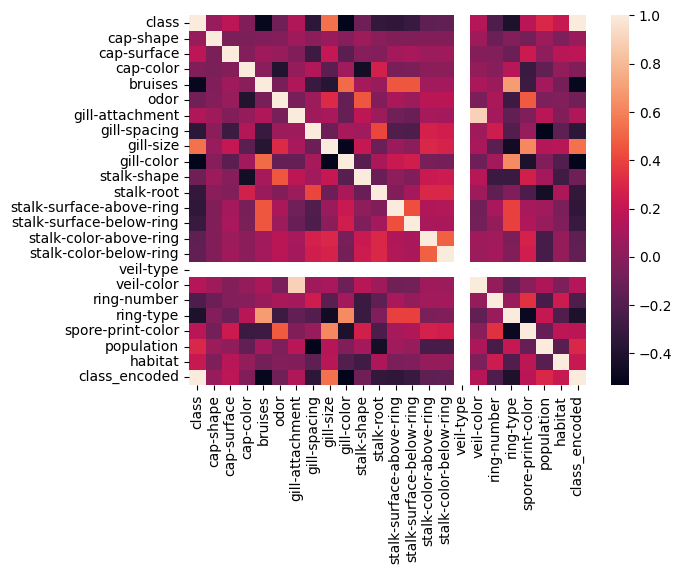

In [62]:
corr = df.corr()
sns.heatmap(corr)

In [50]:
# Trying other models

import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

encode = list()
le = LabelEncoder()

for column in range(len(df.columns)):
    df[df.columns[column]] = le.fit_transform(df[df.columns[column]])
    encode_dict = {index: label for index, label in enumerate(le.classes_)}
    encode.append(encode_dict)

x = df.drop("class", axis = 1)
y = df["class"]

sc = StandardScaler()
x = pd.DataFrame(sc.fit_transform(x), columns = x.columns)

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 42)

model_logreg = LogisticRegression()
model_svm = SVC(C = 1.0, kernel = "rbf")
model_nn = MLPClassifier(hidden_layer_sizes = (128, 128))

In [58]:
model_logreg.fit(x_train, y_train)
model_svm.fit(x_train, y_train)
model_nn.fit(x_train, y_train)

MLPClassifier(hidden_layer_sizes=(128, 128))

In [63]:
print(f"Logistic Regression: {model_logreg.score(x_test, y_test)}")
print(f"SVM: {model_svm.score(x_test, y_test)}")
print(f"Neural Network: {model_nn.score(x_test, y_test)}")

Logistic Regression: 1.0
SVM: 1.0
Neural Network: 1.0
